# Actividad 07 (Unidad II) — Clustering lineal y no lineal, métricas de validación
**Universidad Nacional del Altiplano Puno — Maestría en Ciencia de Datos**
**Datasets:**
1. Iris
2. Moons — sintético, dos medialunas entrelazadas
3. Circles — sintético, dos círculos concéntricos



- **Integrante(s):** Jose Jhonatan Quispe Cartagena - Oscar Edy Vilca Quispe
- **Curso:** Aprendizaje de Máquina I — Grupo A
- **Fecha:** 19/09/2026

## 1. Importación de librerías y funciones auxiliares

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_iris, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.metrics import (
    adjusted_rand_score, v_measure_score, silhouette_score, davies_bouldin_score
)

SEED = 42
np.random.seed(SEED)

In [ ]:
def metodo_del_codo(X, k_max=8, titulo=""):
    """Grafica la inercia de KMeans para k=1..k_max (Método del Codo / Elbow)."""
    inercias = []
    for k in range(1, k_max + 1):
        km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X)
        inercias.append(km.inertia_)
    plt.figure(figsize=(5.5, 3.5))
    plt.plot(range(1, k_max + 1), inercias, marker="o", color="#4C72B0")
    plt.xlabel("Número de clusters (k)")
    plt.ylabel("Inercia")
    plt.title(f"Método del Codo — {titulo}")
    plt.tight_layout()
    plt.show()
    return inercias


def entrenar_modelos(X, n_clusters, dbscan_eps, dbscan_min_samples):
    """Entrena KMeans, DBSCAN y SpectralClustering sobre X (ya estandarizado)."""
    resultados = {}
    resultados["KMeans"] = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10).fit_predict(X)
    resultados["DBSCAN"] = DBSCAN(eps=dbscan_eps, min_samples=dbscan_min_samples).fit_predict(X)
    resultados["SpectralClustering"] = SpectralClustering(
        n_clusters=n_clusters, affinity="nearest_neighbors", n_neighbors=10, random_state=SEED
    ).fit_predict(X)
    return resultados


def calcular_metricas(X, y_true, resultados):
    """Calcula ARI, V-measure (externas) y Silhouette, Davies-Bouldin (internas) por modelo."""
    filas = []
    for modelo, labels in resultados.items():
        n_clusters_encontrados = len(set(labels)) - (1 if -1 in labels else 0)
        n_ruido = int((labels == -1).sum())
        ari = adjusted_rand_score(y_true, labels)
        vm = v_measure_score(y_true, labels)
        if n_clusters_encontrados > 1:
            sil = silhouette_score(X, labels)
            dbi = davies_bouldin_score(X, labels)
        else:
            sil, dbi = np.nan, np.nan
        filas.append({
            "Modelo": modelo,
            "Clusters encontrados": n_clusters_encontrados,
            "Puntos de ruido": n_ruido,
            "ARI (externa)": round(ari, 3),
            "V-measure (externa)": round(vm, 3),
            "Silhouette (interna)": round(sil, 3) if not np.isnan(sil) else np.nan,
            "Davies-Bouldin (interna)": round(dbi, 3) if not np.isnan(dbi) else np.nan,
        })
    return pd.DataFrame(filas).set_index("Modelo")


def graficar_clusters(X2d, y_true, resultados, titulo):
    """Grafica: verdad fundamental + resultado de cada modelo, en un espacio 2D."""
    n_paneles = len(resultados) + 1
    fig, axes = plt.subplots(1, n_paneles, figsize=(4.2 * n_paneles, 4))

    axes[0].scatter(X2d[:, 0], X2d[:, 1], c=y_true, cmap="viridis", s=18)
    axes[0].set_title("Verdad fundamental (y real)")

    for ax, (modelo, labels) in zip(axes[1:], resultados.items()):
        ax.scatter(X2d[:, 0], X2d[:, 1], c=labels, cmap="viridis", s=18)
        ax.set_title(modelo)

    fig.suptitle(titulo)
    plt.tight_layout()
    plt.show()

---
# Caso A — Dataset Iris

In [ ]:
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
print("Dimensiones:", X_iris.shape, "| clases:", dict(zip(iris.target_names, [0, 1, 2])))

scaler_iris = StandardScaler()
X_iris_s = scaler_iris.fit_transform(X_iris)

# PCA únicamente para VISUALIZAR en 2D (el clustering se hace sobre las 4 columnas originales estandarizadas)
X_iris_2d = PCA(n_components=2, random_state=SEED).fit_transform(X_iris_s)

Dimensiones: (150, 4) | clases: {np.str_('setosa'): 0, np.str_('versicolor'): 1, np.str_('virginica'): 2}


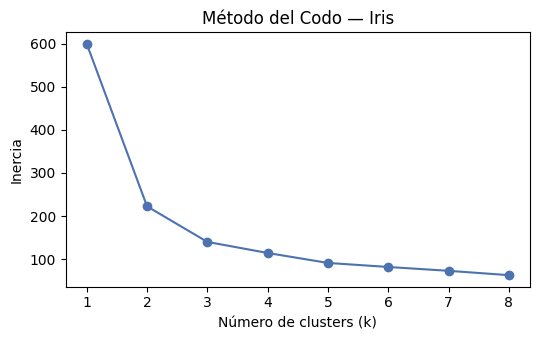

In [ ]:
_ = metodo_del_codo(X_iris_s, k_max=8, titulo="Iris")

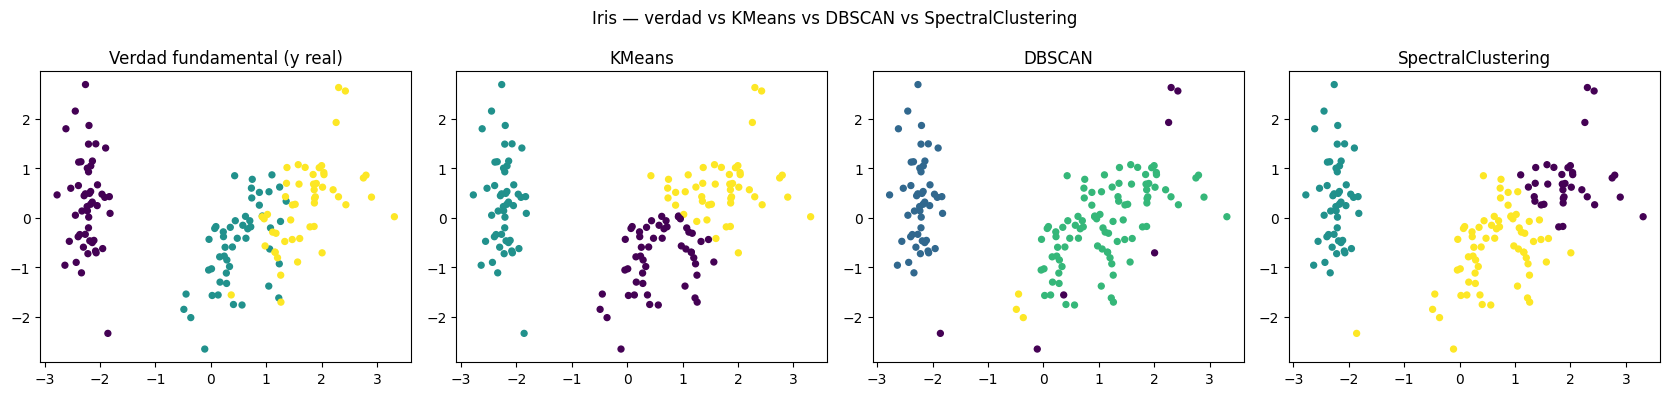

In [ ]:
resultados_iris = entrenar_modelos(X_iris_s, n_clusters=3, dbscan_eps=0.65, dbscan_min_samples=3)
graficar_clusters(X_iris_2d, y_iris, resultados_iris, "Iris — verdad vs KMeans vs DBSCAN vs SpectralClustering")

In [ ]:
metricas_iris = calcular_metricas(X_iris_s, y_iris, resultados_iris)
metricas_iris

,Clusters encontrados,Puntos de ruido,ARI (externa),V-measure (externa),Silhouette (interna),Davies-Bouldin (interna)
Modelo,,,,,,
KMeans,3,0,0.620,0.659,0.460,0.834
DBSCAN,3,7,0.537,0.645,0.353,14.321
SpectralClustering,3,0,0.646,0.684,0.459,0.822


### ¿Qué significan las métricas obtenidas en Iris?
Los 3 modelos encuentran los 3 clusters esperados, pero ninguno logra un ARI muy alto (0.537–0.646) porque versicolor y virginica se solapan en el espacio de características, no hay una separación perfecta posible. SpectralClustering es el mejor en ambas métricas externas (ARI=0.646, V-measure=0.684), seguido de cerca por KMeans. DBSCAN queda último (ARI=0.537) y además deja 7 puntos como ruido, porque en la zona de solape la densidad baja y esos puntos no alcanzan el umbral min_samples. Su Davies-Bouldin (14.321) es dramáticamente peor que el de los otros dos (~0.83) un cluster pequeño y disperso generado por DBSCAN distorsiona esta métrica interna, algo que ARI/V-measure no reflejan porque esos puntos sí pertenecían a su clase real. Conclusión: en Iris, un dataset con clusters moderadamente convexos, KMeans y SpectralClustering superan a DBSCAN.

- **Método del codo:** la inercia cae fuerte de k=1 a k=3 y luego se aplana, el "codo" sugiere entre 2 y 3 grupos, coherente con que Iris tiene 3 especies, aunque dos de ellas (versicolor y virginica) se solapan bastante en el espacio de características.
- **ARI y V-measure (externas):** KMeans y SpectralClustering obtienen valores de ARI/V-measure moderados-altos (~0.55–0.65), porque logran separar bien *setosa* (que es linealmente separable de las otras dos) pero cometen errores entre *versicolor* y *virginica*, que no son perfectamente separables ni en línea recta ni por densidad. DBSCAN, al ser basado en densidad, tiende a fusionar parte de esas dos especies solapadas en un mismo cluster o a dejarlas como ruido, lo que explica que su ARI sea algo más bajo.
- **Silhouette y Davies-Bouldin (internas):** los valores de Silhouette son moderados (~0.35–0.46, ni muy cerca de 1 ni de 0), reflejando que los clusters existen pero no están perfectamente separados, consistente con el solapamiento visto arriba. El Davies-Bouldin de DBSCAN es notablemente peor que el de KMeans/Spectral: esto ocurre porque DBSCAN puede generar un cluster minúsculo (pocos puntos densos) que distorsiona la métrica, un efecto que no capturan ARI/V-measure porque esos puntos sí pertenecían realmente a esa clase.

---
# Caso B — Dataset Moons

In [ ]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.07, random_state=SEED)
print("Dimensiones:", X_moons.shape, "| clases:", set(y_moons))

scaler_moons = StandardScaler()
X_moons_s = scaler_moons.fit_transform(X_moons)
# Moons ya es 2D, no hace falta PCA para graficar
X_moons_2d = X_moons_s

Dimensiones: (300, 2) | clases: {np.int64(0), np.int64(1)}


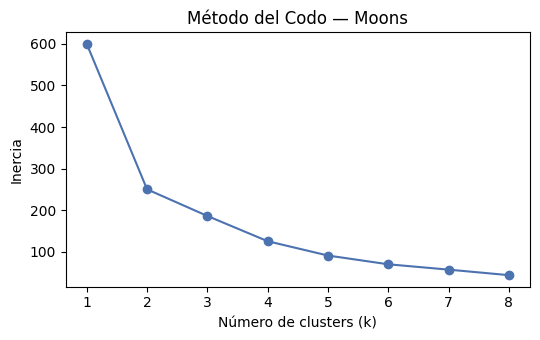

In [ ]:
_ = metodo_del_codo(X_moons_s, k_max=8, titulo="Moons")

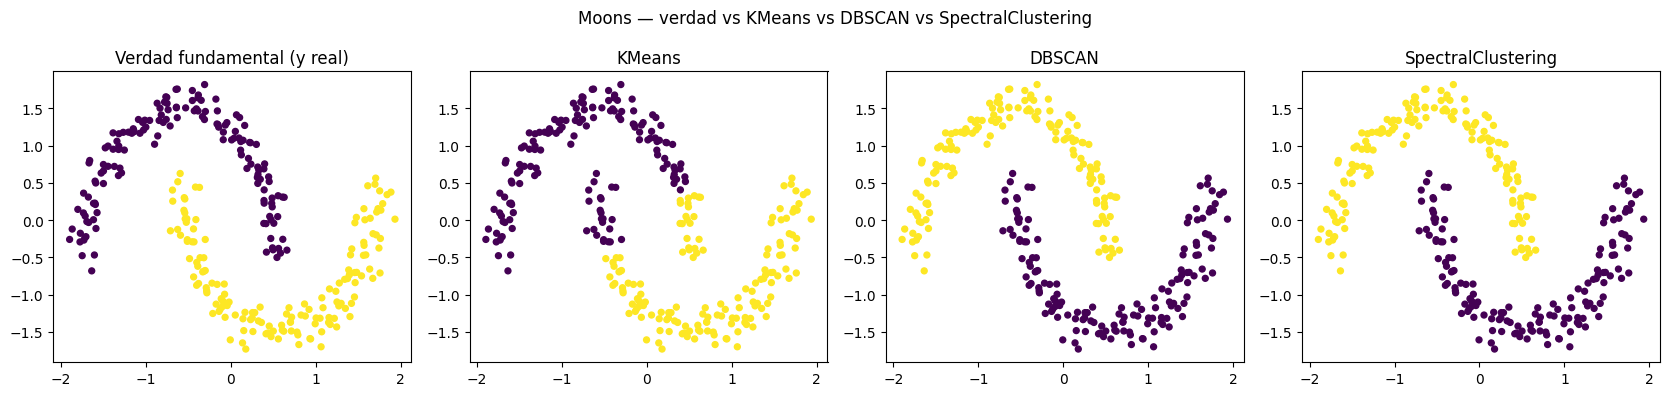

In [ ]:
resultados_moons = entrenar_modelos(X_moons_s, n_clusters=2, dbscan_eps=0.24, dbscan_min_samples=3)
graficar_clusters(X_moons_2d, y_moons, resultados_moons, "Moons — verdad vs KMeans vs DBSCAN vs SpectralClustering")

In [ ]:
metricas_moons = calcular_metricas(X_moons_s, y_moons, resultados_moons)
metricas_moons

,Clusters encontrados,Puntos de ruido,ARI (externa),V-measure (externa),Silhouette (interna),Davies-Bouldin (interna)
Modelo,,,,,,
KMeans,2,0,0.479,0.382,0.495,0.806
DBSCAN,2,0,1.000,1.000,0.382,1.023
SpectralClustering,2,0,1.000,1.000,0.382,1.023


### ¿Qué significan las métricas obtenidas en Moons? (2 pts)
Aquí se ve con claridad el límite de KMeans: ARI=0.479 y V-measure=0.382, muy por debajo de DBSCAN y SpectralClustering, que llegan ambos a 1.000 en ARI y V-measure (acierto perfecto). La razón es geométrica: las medialunas no son separables con una línea recta, y KMeans solo traza fronteras lineales. DBSCAN (densidad) y SpectralClustering (grafo de vecinos) sí pueden seguir la curva de cada medialuna. Dato interesante: aun con acierto perfecto, el Silhouette de DBSCAN/Spectral (0.382) no es alto, porque el Silhouette también asume forma convexa, y una medialuna no lo es. Un Silhouette moderado aquí no significa que el clustering esté mal. Conclusión: DBSCAN y SpectralClustering son claramente mejores que KMeans en Moons

- **Método del codo:** la curva de inercia baja de forma suave y continua, **sin un codo claro** en k=2. Esto es esperado: el método del codo mide distancia euclidiana a un centroide, una noción que asume clusters compactos/convexos, pero las medialunas no son convexas, así que esta métrica interna no es útil aquí, aunque sepamos (por la verdad fundamental) que el número correcto de grupos es 2.
- **ARI y V-measure (externas):** KMeans obtiene un ARI/V-measure notablemente más bajo que DBSCAN y SpectralClustering, porque KMeans solo traza fronteras lineales y corta las dos medialunas por la mitad en vez de separarlas. DBSCAN y SpectralClustering, al permitir fronteras no lineales, alcanzan ARI y V-measure prácticamente perfectos (~1.0): DBSCAN porque sigue la densidad continua de cada medialuna, y SpectralClustering porque usa el grafo de vecinos más cercanos, que respeta la forma curva de los datos.
- **Silhouette y Davies-Bouldin (internas):** aun cuando DBSCAN/Spectral acertaron casi perfectamente según la verdad fundamental, su Silhouette no es cercano a 1 (ronda ~0.38),  porque estas métricas internas asumen forma convexa/compacta, y una medialuna, aunque sea 'un solo cluster correcto', no es compacta en el sentido euclidiano. **Esta es una lección clave:** una métrica interna baja no siempre significa que el clustering esté mal; puede significar que los clusters reales no son convexos.

---
# Caso C — Dataset Circles

In [ ]:
X_circles, y_circles = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=SEED)
print("Dimensiones:", X_circles.shape, "| clases:", set(y_circles))

scaler_circles = StandardScaler()
X_circles_s = scaler_circles.fit_transform(X_circles)
X_circles_2d = X_circles_s

Dimensiones: (300, 2) | clases: {np.int64(0), np.int64(1)}


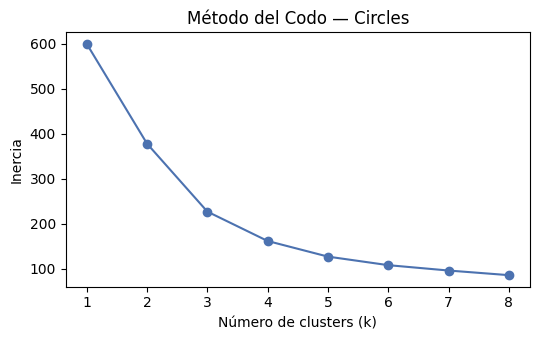

In [ ]:
_ = metodo_del_codo(X_circles_s, k_max=8, titulo="Circles")

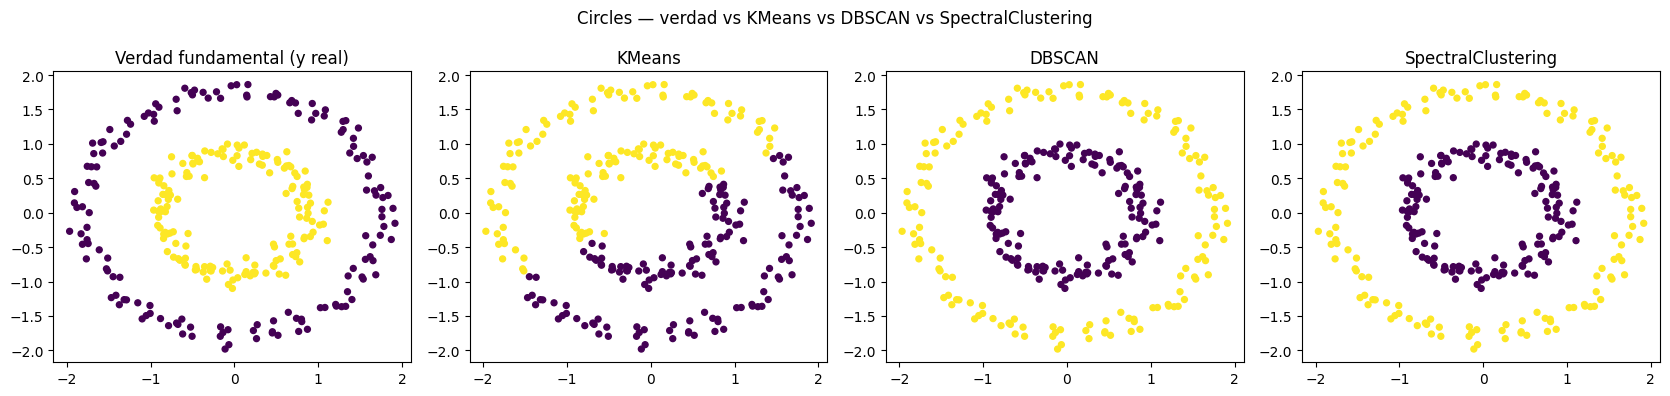

In [ ]:
resultados_circles = entrenar_modelos(X_circles_s, n_clusters=2, dbscan_eps=0.32, dbscan_min_samples=3)
graficar_clusters(X_circles_2d, y_circles, resultados_circles, "Circles — verdad vs KMeans vs DBSCAN vs SpectralClustering")

In [ ]:
metricas_circles = calcular_metricas(X_circles_s, y_circles, resultados_circles)
metricas_circles

,Clusters encontrados,Puntos de ruido,ARI (externa),V-measure (externa),Silhouette (interna),Davies-Bouldin (interna)
Modelo,,,,,,
KMeans,2,0,-0.003,0.0,0.353,1.175
DBSCAN,2,0,1.000,1.0,0.110,163.270
SpectralClustering,2,0,1.000,1.0,0.110,163.270


### ¿Qué significan las métricas obtenidas en Circles?
El caso más extremo de los tres. KMeans obtiene ARI=-0.003 (prácticamente idéntico a asignar clusters al azar), porque ambos círculos comparten el mismo centro y no existe ninguna línea recta que los separe. DBSCAN y SpectralClustering vuelven a lograr ARI=1.000 y V-measure=1.000, acierto perfecto. Pero ocurre la paradoja más importante de toda la actividad: su Silhouette es muy bajo (0.110) y su Davies-Bouldin es altísimo (163.270 — muchísimo peor que el 1.175 de KMeans, que en realidad falló). Esto pasa porque ambos círculos comparten centro: cualquier métrica interna basada en distancia a un centroide "ve" a los dos clusters muy cerca uno del otro, aunque estén perfectamente separados según la verdad real. Conclusión: en Circles, las métricas internas contradicen directamente a las externas — hay que confiar en las externas cuando se tienen etiquetas reales.

- **Método del codo:** al igual que en Moons, la curva no muestra un codo claro en k=2 , círculos concéntricos son el ejemplo más extremo de estructura no convexa, así que un criterio basado en distancia a un centroide (como la inercia) no puede "ver" la estructura real de los datos.
- **ARI y V-measure (externas):** este es el caso más dramático de los tres. KMeans obtiene un **ARI cercano a 0** (tan malo como una asignación aleatoria), porque el centro de ambos círculos es el mismo punto, no existe ninguna línea recta que separe el círculo interior del exterior. DBSCAN y SpectralClustering, en cambio, alcanzan **ARI y V-measure = 1.0** (perfectos), porque ambos pueden seguir la curvatura de los datos: DBSCAN mediante densidad conectada, y SpectralClustering mediante el grafo de vecinos.
- **Silhouette y Davies-Bouldin (internas):** aquí ocurre la paradoja más clara de la actividad: a pesar de que DBSCAN y SpectralClustering acertaron el 100% del clustering (ARI=1.0), su Silhouette es muy bajo (~0.11) y su Davies-Bouldin es muy alto/malo (por encima de 100), mucho peor que el de KMeans, que en realidad hizo un mal trabajo. Esto sucede porque el círculo interior y el exterior comparten el mismo centro; cualquier métrica interna basada en distancia a un centroide interpretará que ambos clusters están "muy cerca" y por lo tanto mal separados, aunque en realidad estén perfectamente separados según la verdad fundamental. **Conclusión práctica: cuando la estructura real de los datos no es convexa, las métricas internas pueden contradecir a las métricas externas, y hay que confiar en estas últimas (si se tiene la verdad fundamental disponible).**

---
# 2. Naturaleza lineal / no lineal y hiperparámetros críticos

In [ ]:
naturaleza = pd.DataFrame({
    "Modelo": ["KMeans", "DBSCAN", "SpectralClustering"],
    "Naturaleza": [
        "Lineal (fronteras convexas — hiperplanos entre centroides)",
        "Lineal y no lineal (se basa en densidad, no en distancia a un centro)",
        "No lineal (usa un grafo de similitud/vecinos, no distancia directa)",
    ],
    "Hiperparámetros críticos": [
        "n_clusters (debe conocerse de antemano); inicialización de centroides",
        "eps (radio de vecindad) y min_samples (densidad mínima) — muy sensibles a la escala de los datos",
        "n_clusters (debe conocerse); affinity y sus parámetros (n_neighbors o gamma) — definen cómo se construye el grafo",
    ],
    "Evidencia en esta actividad": [
        "Buen desempeño en Iris; deficiente en Moons; prácticamente aleatorio en Circles (ARI≈0)",
        "Muy sensible al ajuste de eps/min_samples; con buen ajuste logra ARI=1.0 en Moons y Circles",
        "Con affinity='nearest_neighbors', logra ARI=1.0 en Moons y Circles, y el mejor ARI en Iris",
    ],
})
naturaleza

,Modelo,Naturaleza,Hiperparámetros críticos,Evidencia en esta actividad
0,KMeans,Lineal (fronteras convexas — hiperplanos entre...,n_clusters (debe conocerse de antemano); inici...,Buen desempeño en Iris; deficiente en Moons; p...
1,DBSCAN,"Lineal y no lineal (se basa en densidad, no en...",eps (radio de vecindad) y min_samples (densida...,Muy sensible al ajuste de eps/min_samples; con...
2,SpectralClustering,"No lineal (usa un grafo de similitud/vecinos, ...",n_clusters (debe conocerse); affinity y sus pa...,"Con affinity='nearest_neighbors', logra ARI=1...."


---
# 3. Resumen comparativo general

In [ ]:
resumen_total = pd.concat({
    "Iris": metricas_iris,
    "Moons": metricas_moons,
    "Circles": metricas_circles,
}, names=["Dataset", "Modelo"])
resumen_total

Clusters encontrados  Puntos de ruido  \
Dataset Modelo                                                      
Iris    KMeans                                 3                0   
        DBSCAN                                 3                7   
        SpectralClustering                     3                0   
Moons   KMeans                                 2                0   
        DBSCAN                                 2                0   
        SpectralClustering                     2                0   
Circles KMeans                                 2                0   
        DBSCAN                                 2                0   
        SpectralClustering                     2                0   

                            ARI (externa)  V-measure (externa)  \
Dataset Modelo                                                   
Iris    KMeans                      0.620                0.659   
        DBSCAN                      0.537                0.645   
        SpectralClustering          0.646                0.684   
Moons   KMeans                      0.479                0.382   
        DBSCAN                      1.000                1.000   
        SpectralClustering          1.000                1.000   
Circles KMeans                     -0.003                0.000   
        DBSCAN                      1.000                1.000   
        SpectralClustering          1.000                1.000   

                            Silhouette (interna)  Davies-Bouldin (interna)  
Dataset Modelo                                                              
Iris    KMeans                             0.460                     0.834  
        DBSCAN                             0.353                    14.321  
        SpectralClustering                 0.459                     0.822  
Moons   KMeans                             0.495                     0.806  
        DBSCAN                             0.382                     1.023  
        SpectralClustering                 0.382                     1.023  
Circles KMeans                             0.353                     1.175  
        DBSCAN                             0.110                   163.270  
        SpectralClustering                 0.110                   163.270

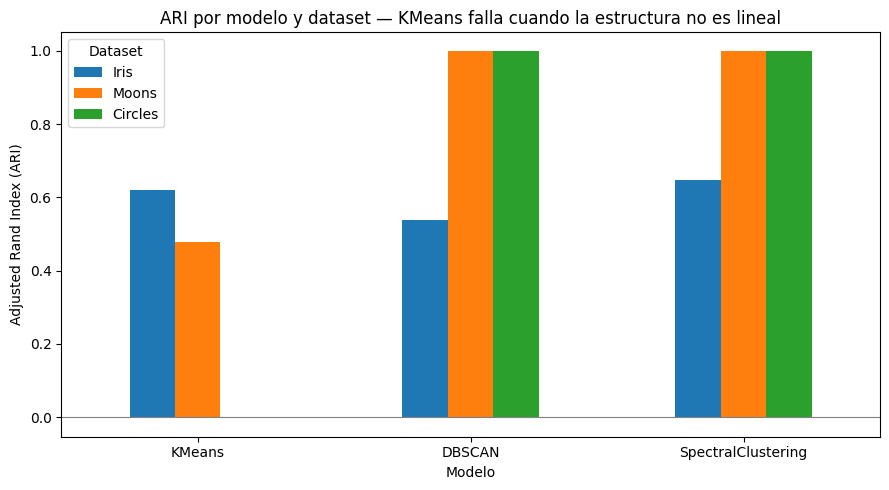

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
resumen_total["ARI (externa)"].unstack("Dataset").plot(kind="bar", ax=ax)
ax.set_ylabel("Adjusted Rand Index (ARI)")
ax.set_title("ARI por modelo y dataset — KMeans falla cuando la estructura no es lineal")
ax.axhline(0, color="grey", linewidth=0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Conclusión general

Viendo los tres datasets juntos, el patrón es consistente: el desempeño de KMeans se degrada exactamente en la medida en que la estructura deja de ser convexa (Iris: aceptable -> Moons: pobre -> Circles: nulo), mientras que DBSCAN y SpectralClustering se mantienen perfectos en Moons y Circles (ARI=1.000) precisamente porque no dependen de fronteras lineales. Además, quedó demostrado con evidencia concreta (Circles) que las métricas internas (Silhouette, Davies-Bouldin) pueden contradecir a las externas cuando los clusters reales no son convexos, por lo que la recomendación práctica es: si hay etiquetas reales disponibles, priorizar ARI/V-measure sobre Silhouette/Davies-Bouldin.

- El factor decisivo en esta actividad no fue "qué tan bueno" es cada algoritmo en general, sino **si la geometría de los datos es convexa o no**: KMeans (lineal) funciona razonablemente en Iris (clusters aproximadamente convexos) pero falla en Moons y falla por completo en Circles (estructuras no convexas).
- DBSCAN y SpectralClustering (ambos capaces de capturar estructuras no lineales) mantienen un desempeño alto en los tres datasets, siempre que sus hiperparámetros críticos (`eps`/`min_samples` para DBSCAN; `affinity`/`n_neighbors` para Spectral) estén bien ajustados a la escala de los datos.
- Las métricas externas (ARI, V-measure) y las internas (Silhouette, Davies-Bouldin) **no siempre están de acuerdo**: en Circles, las internas califican como "malo" un resultado que las externas confirman como perfecto, porque las métricas internas asumen forma convexa. Esto enseña que, si se dispone de etiquetas reales (validación externa), estas deben priorizarse sobre las métricas internas al evaluar clustering en datos con formas no convexas.
- El método del codo, al basarse en inercia (distancia euclidiana a centroides), solo es realmente informativo cuando los clusters subyacentes son convexos (como en Iris); en Moons y Circles no muestra un codo claro, aun cuando el número real de grupos (k=2) es conocido.